## import library

In [ ]:
import pandas as pd

# import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cluster import KMeans
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    silhouette_score,
    roc_auc_score,
    roc_curve,
)

sns.set_theme(style="whitegrid")


## Load Dataset

In [86]:
df = pd.read_csv("HTRU_2.csv", header=None)

df.columns = [
    "mean_profile",
    "std_profile",
    "skewness_profile",
    "kurtosis_profile",
    "mean_dm_snr",
    "std_dm_snr",
    "skewness_dm_snr",
    "kurtosis_dm_snr",
    "class",
]

df.head()


,mean_profile,std_profile,skewness_profile,kurtosis_profile,mean_dm_snr,std_dm_snr,skewness_dm_snr,kurtosis_dm_snr,class
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0


 ## Info & Struktur Data

In [87]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17898 entries, 0 to 17897
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   mean_profile      17898 non-null  float64
 1   std_profile       17898 non-null  float64
 2   skewness_profile  17898 non-null  float64
 3   kurtosis_profile  17898 non-null  float64
 4   mean_dm_snr       17898 non-null  float64
 5   std_dm_snr        17898 non-null  float64
 6   skewness_dm_snr   17898 non-null  float64
 7   kurtosis_dm_snr   17898 non-null  float64
 8   class             17898 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 1.2 MB


,mean_profile,std_profile,skewness_profile,kurtosis_profile,mean_dm_snr,std_dm_snr,skewness_dm_snr,kurtosis_dm_snr,class
count,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000
mean,111.079968,46.549532,0.477857,1.770279,12.614400,26.326515,8.303556,104.857709,0.091574
std,25.652935,6.843189,1.064040,6.167913,29.472897,19.470572,4.506092,106.514540,0.288432
min,5.812500,24.772042,-1.876011,-1.791886,0.213211,7.370432,-3.139270,-1.976976,0.000000
25%,100.929688,42.376018,0.027098,-0.188572,1.923077,14.437332,5.781506,34.960504,0.000000
50%,115.078125,46.947479,0.223240,0.198710,2.801839,18.461316,8.433515,83.064556,0.000000
75%,127.085938,51.023202,0.473325,0.927783,5.464256,28.428104,10.702959,139.309330,0.000000
max,192.617188,98.778911,8.069522,68.101622,223.392141,110.642211,34.539844,1191.000837,1.000000


## DATA PREPROCESSING

### Cek Missing Values

In [88]:
df.isnull().sum()

mean_profile        0
std_profile         0
skewness_profile    0
kurtosis_profile    0
mean_dm_snr         0
std_dm_snr          0
skewness_dm_snr     0
kurtosis_dm_snr     0
class               0
dtype: int64

### Cek & Hapus Duplikasi

In [89]:
print(df.duplicated().sum())
df = df.drop_duplicates()
df.shape


0


(17898, 9)

### Pisahkan Fitur & Label

In [90]:
X = df.drop(columns=["class"])
y = df["class"]


### Standarisasi Dengan Benar

In [91]:
scaler = StandardScaler()

# Fit dan transform fitur
X_scaled = scaler.fit_transform(X)


### Train-Test Split

In [92]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


### Distribusi Label

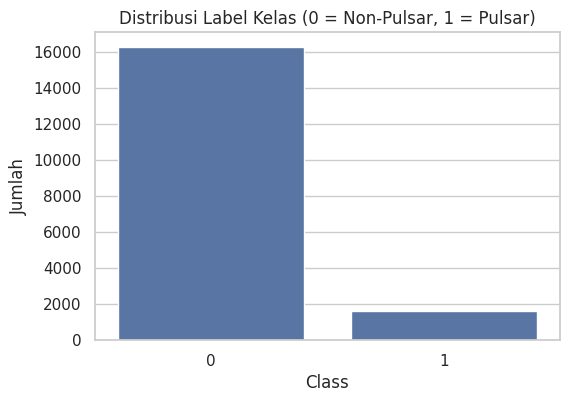

class
0    16259
1     1639
Name: count, dtype: int64

In [93]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title("Distribusi Label Kelas (0 = Non-Pulsar, 1 = Pulsar)")
plt.xlabel("Class")
plt.ylabel("Jumlah")
plt.show()

y.value_counts()

### Penanganan Imbalanced Data

**Distribusi Kelas:**
Dataset HTRU2 memiliki distribusi kelas yang imbalanced, di mana kelas 0 (non-pulsar) jauh lebih banyak daripada kelas 1 (pulsar). Ini wajar karena pulsar adalah objek langka di astronomi.

**Tantangan dalam Machine Learning:**
Ketidakseimbangan alami ini dapat menyebabkan model menjadi bias ke kelas mayoritas (kelas 0) dan gagal mendeteksi pulsar. Model mungkin akan memiliki akurasi tinggi hanya dengan menebak "bukan pulsar" setiap saat. Oleh karena itu, pada tahap preprocessing, kita perlu menerapkan teknik penanganan imbalanced data (seperti **SMOTE**) untuk meningkatkan kemampuan model dalam mengenali pola kelas minoritas (pulsar).

In [94]:
# Initialize SMOTE
smote = SMOTE(random_state=42)

# Fit SMOTE pada data pelatihan
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train) # type: ignore

print("Distribusi kelas sebelum SMOTE:\n", y_train.value_counts())
print("\nDistribusi kelas setelah SMOTE:\n", y_train_resampled.value_counts())


Distribusi kelas sebelum SMOTE:
 class
0    13007
1     1311
Name: count, dtype: int64

Distribusi kelas setelah SMOTE:
 class
1    13007
0    13007
Name: count, dtype: int64


## EDA

### Histogram Setiap Fitur (Distribusi Data)

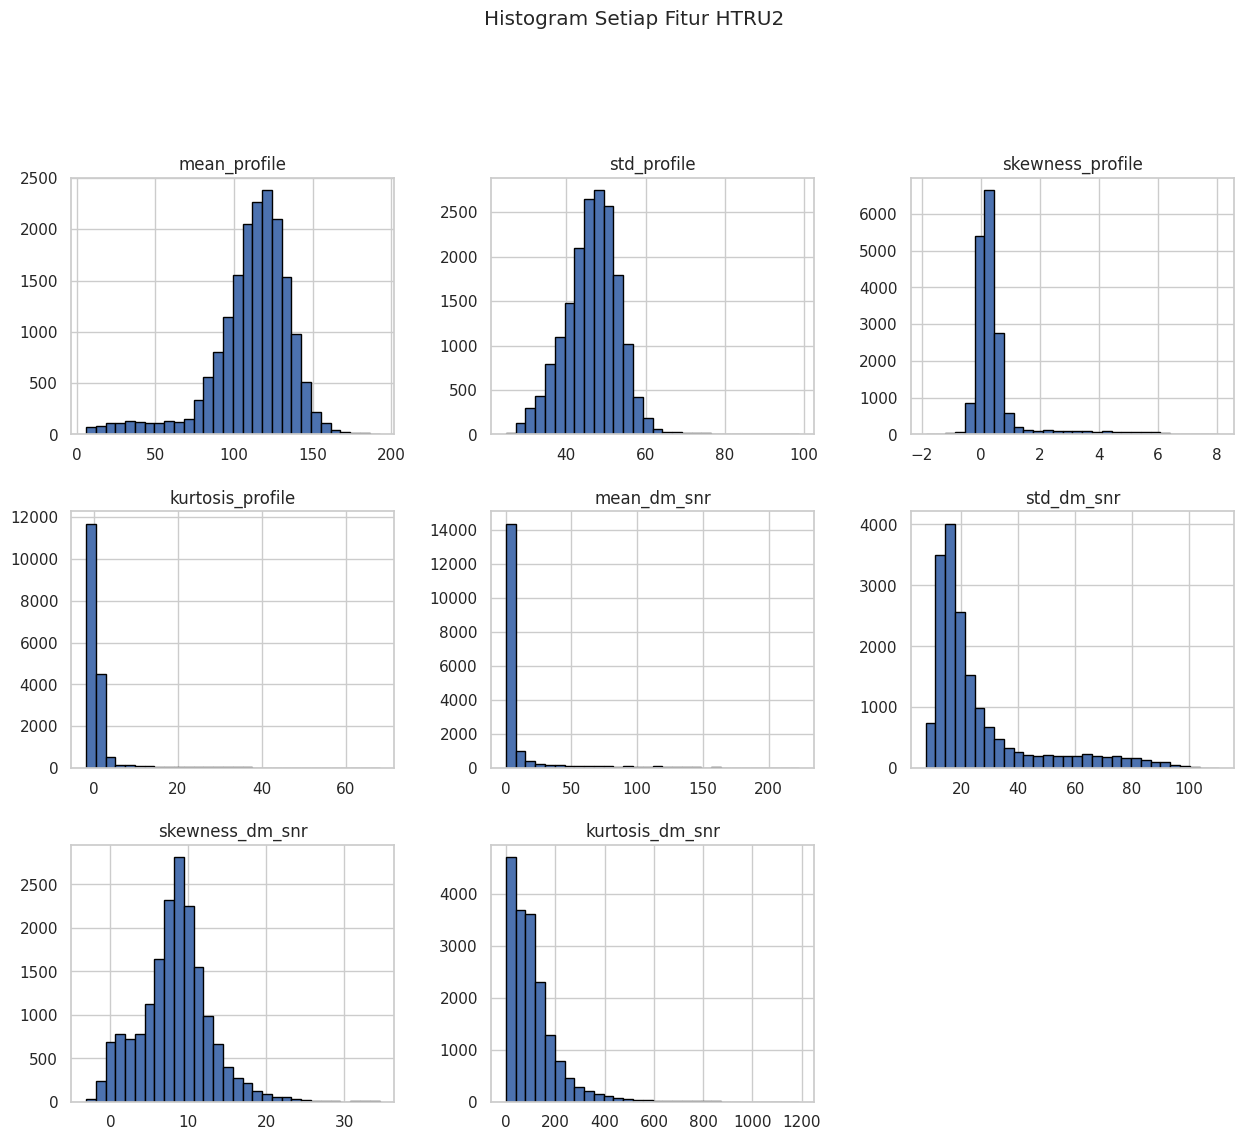

In [95]:
df.drop(columns=["class"]).hist(bins=30, figsize=(15, 12), edgecolor="black")
plt.suptitle("Histogram Setiap Fitur HTRU2", y=1.02)
plt.show()

### Boxplot Fitur (Deteksi Outlier)

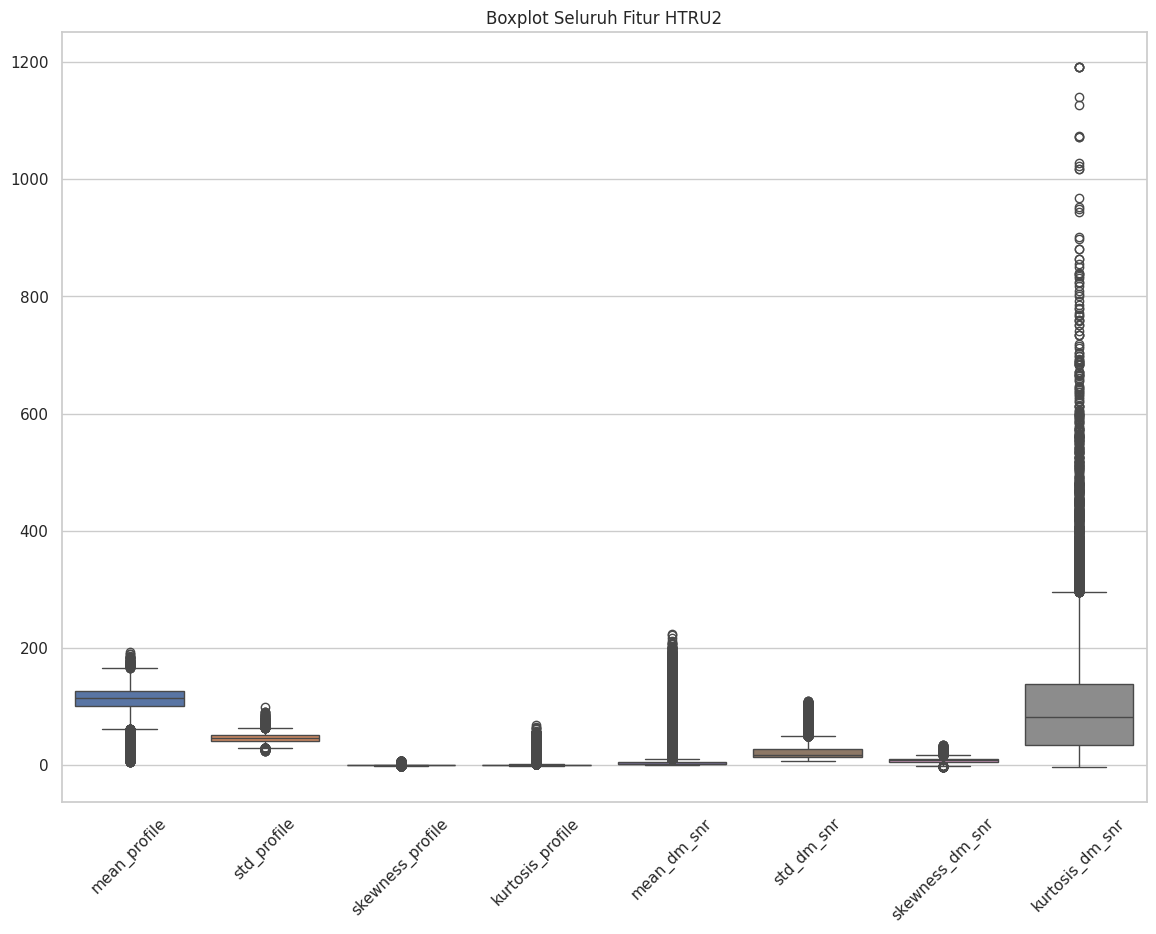

In [96]:
plt.figure(figsize=(14, 10))
sns.boxplot(data=df.drop(columns=["class"]))
plt.title("Boxplot Seluruh Fitur HTRU2")
plt.xticks(rotation=45)
plt.show()


### Heatmap Korelasi Antar Fitur

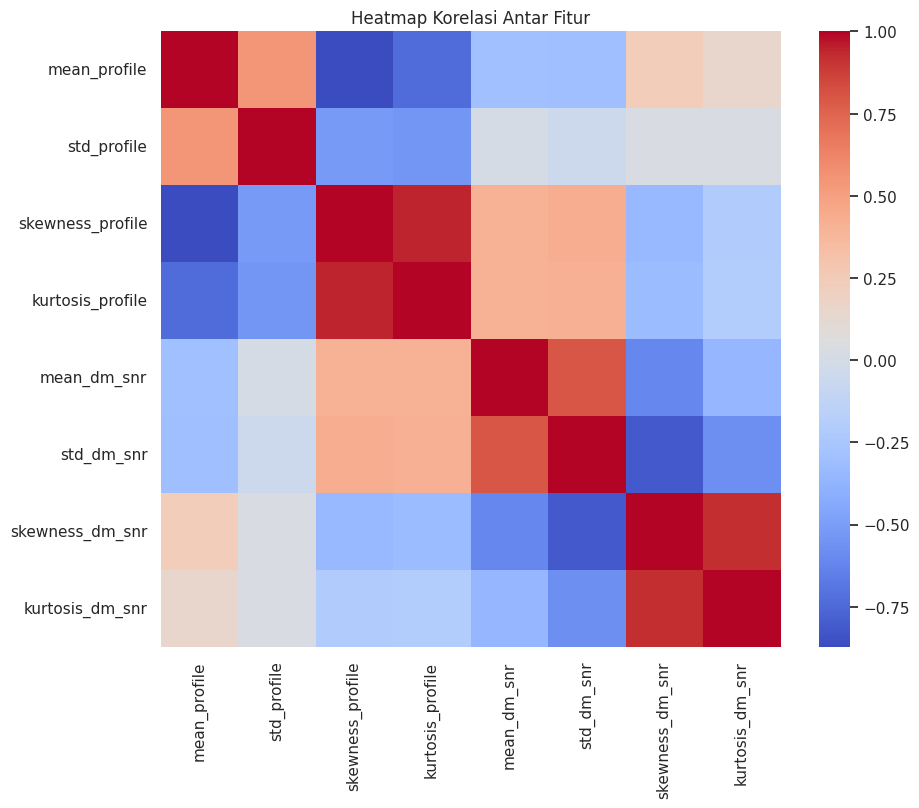

In [97]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.drop(columns=["class"]).corr(), annot=False, cmap="coolwarm")
plt.title("Heatmap Korelasi Antar Fitur")
plt.show()

### Pairplot (Opsional, Lama Diproses)

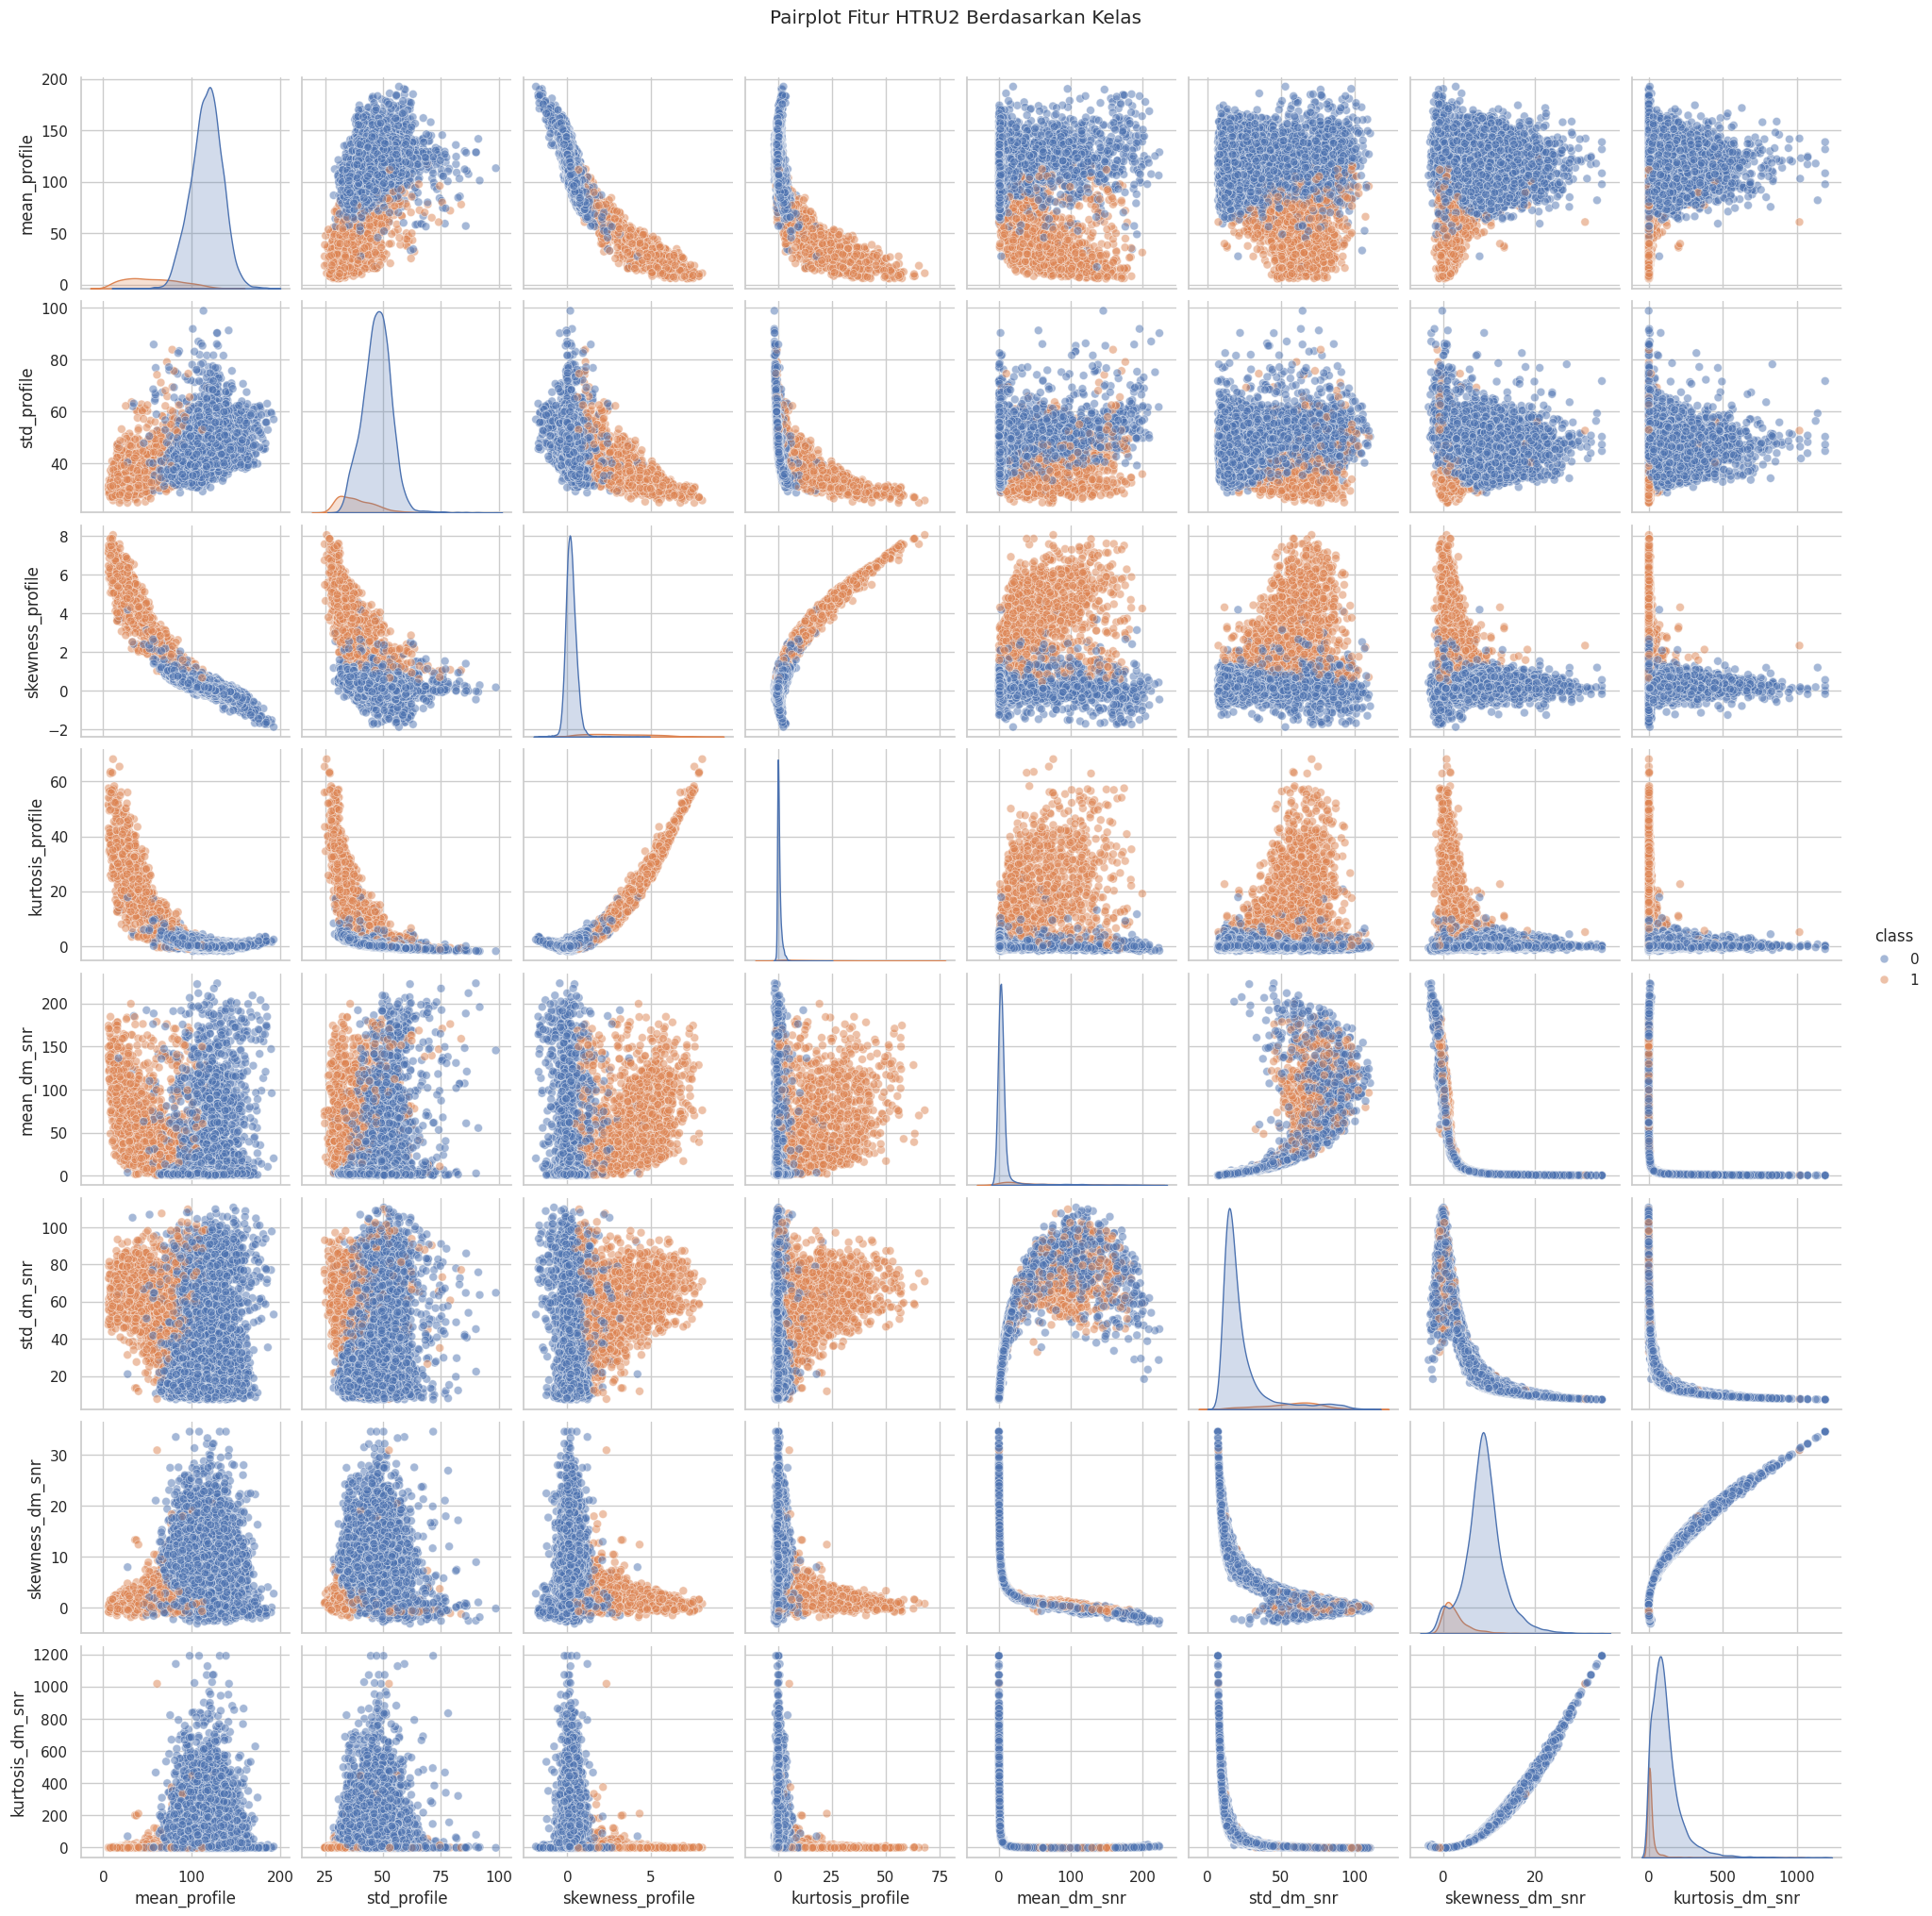

In [98]:
sns.pairplot(df, hue="class", diag_kind="kde", plot_kws={"alpha": 0.5, "s": 40})
plt.suptitle("Pairplot Fitur HTRU2 Berdasarkan Kelas", y=1.02)
plt.show()


### PCA Visualisasi 2D

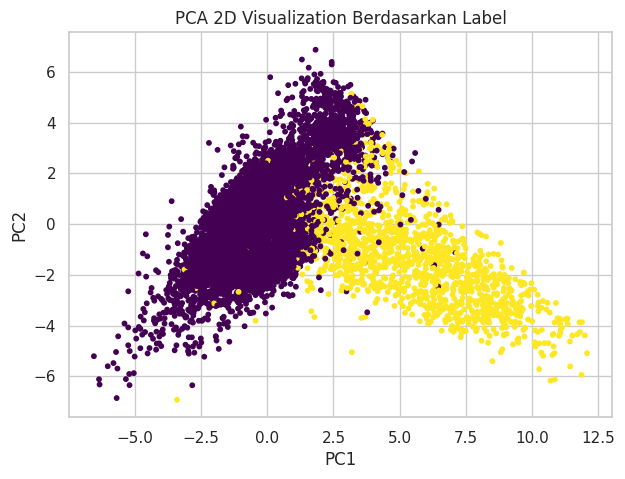

Explained Variance Ratio: [0.51675584 0.26807564]


In [99]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=y, cmap="viridis", s=10)

plt.title("PCA 2D Visualization Berdasarkan Label")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()
print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")

Exploratory Data Analysis dilakukan untuk memahami karakteristik awal dari dataset HTRU2.
Dari hasil analisis, diperoleh beberapa temuan penting:
	
	1. Distribusi label sangat imbalanced, dengan kelas non-pulsar (0) jauh lebih banyak daripada kelas pulsar (1).
	2. Distribusi fitur bersifat skewed dan memiliki banyak outlier, namun outlier tidak dihapus karena merupakan bagian alami dari sinyal radio.
	3. Korelasi antar fitur relatif kecil sehingga setiap fitur memiliki kontribusi yang cukup independen.
	4. PCA dua dimensi menunjukkan bahwa terdapat pola pemisahan antara sinyal pulsar dan non-pulsar, meskipun tidak sempurna.

Temuan-temuan ini menjadi dasar kuat untuk pemilihan metode klasifikasi (Decision Tree) dan metode clustering pada tahap analisis berikutnya.

## CLASSIFICATION (Decision Tree)

### Inisialisasi & Train Decision Tree

In [100]:
# Modeling dengan Hyperparameter Tuning

# Tentukan parameter yang ingin dicoba
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [5, 10, 15, 20, None],  # Mencegah pohon terlalu dalam (overfitting)
    "min_samples_split": [2, 5, 10],  # Syarat minimal membelah node
    "min_samples_leaf": [1, 2, 4],  # Syarat minimal data di daun
}

# Inisialisasi Decision Tree
dt = DecisionTreeClassifier(random_state=42)

# Cari parameter terbaik dengan GridSearchCV
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,  # 5-fold Cross Validation
    scoring="f1",  # Fokus pada F1-Score karena imbalanced
    n_jobs=-1,
    verbose=1,
)

# Latih model pada data yang sudah di-SMOTE
grid_search.fit(X_train_resampled, y_train_resampled) # type: ignore

# Ambil model terbaik
best_dt_model = grid_search.best_estimator_

print("Parameter Terbaik:", grid_search.best_params_)
print("Skor Validasi Terbaik (F1):", grid_search.best_score_)


Fitting 5 folds for each of 90 candidates, totalling 450 fits
Parameter Terbaik: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2}
Skor Validasi Terbaik (F1): 0.9633880257326128


### Prediksi & Evaluasi

In [ ]:
# Prediksi menggunakan model terbaik
y_pred = best_dt_model.predict(X_test)
y_pred_proba = best_dt_model.predict_proba(X_test)[:, 1] # type: ignore

# Hitung Metrik
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.96      0.97      3252
           1       0.68      0.87      0.76       328

    accuracy                           0.95      3580
   macro avg       0.83      0.91      0.87      3580
weighted avg       0.96      0.95      0.95      3580

Confusion Matrix:
 [[3118  134]
 [  43  285]]


#### Plot Confusion Matrix

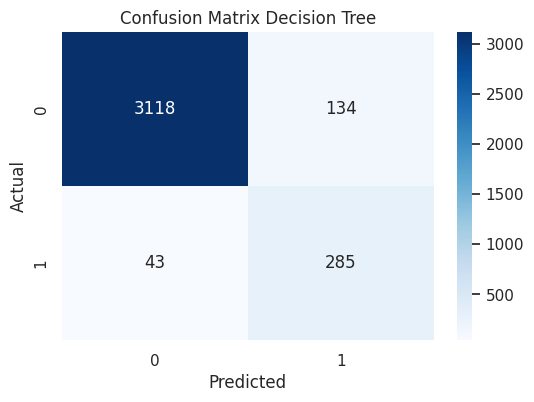

In [111]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Decision Tree")
plt.show()

#### Plot ROC-AUC

ROC-AUC Score: 0.9148


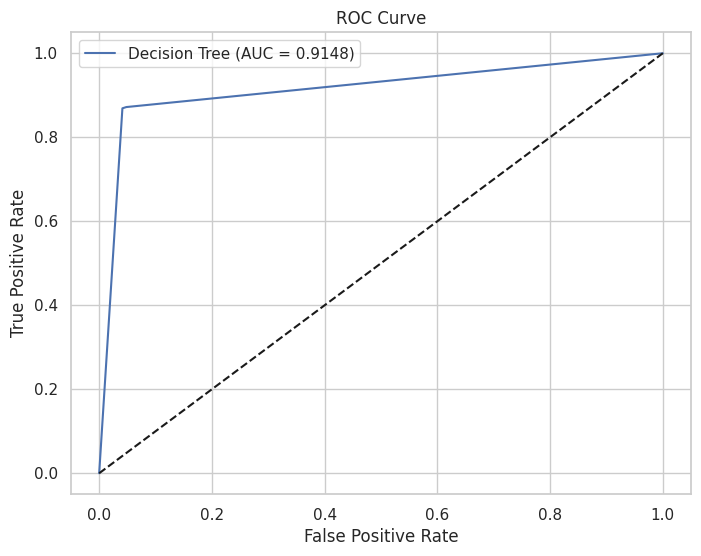

In [103]:
# Hitung & Tampilkan ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Decision Tree (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


### Visualisasi Decision Tree (max_depth=3)

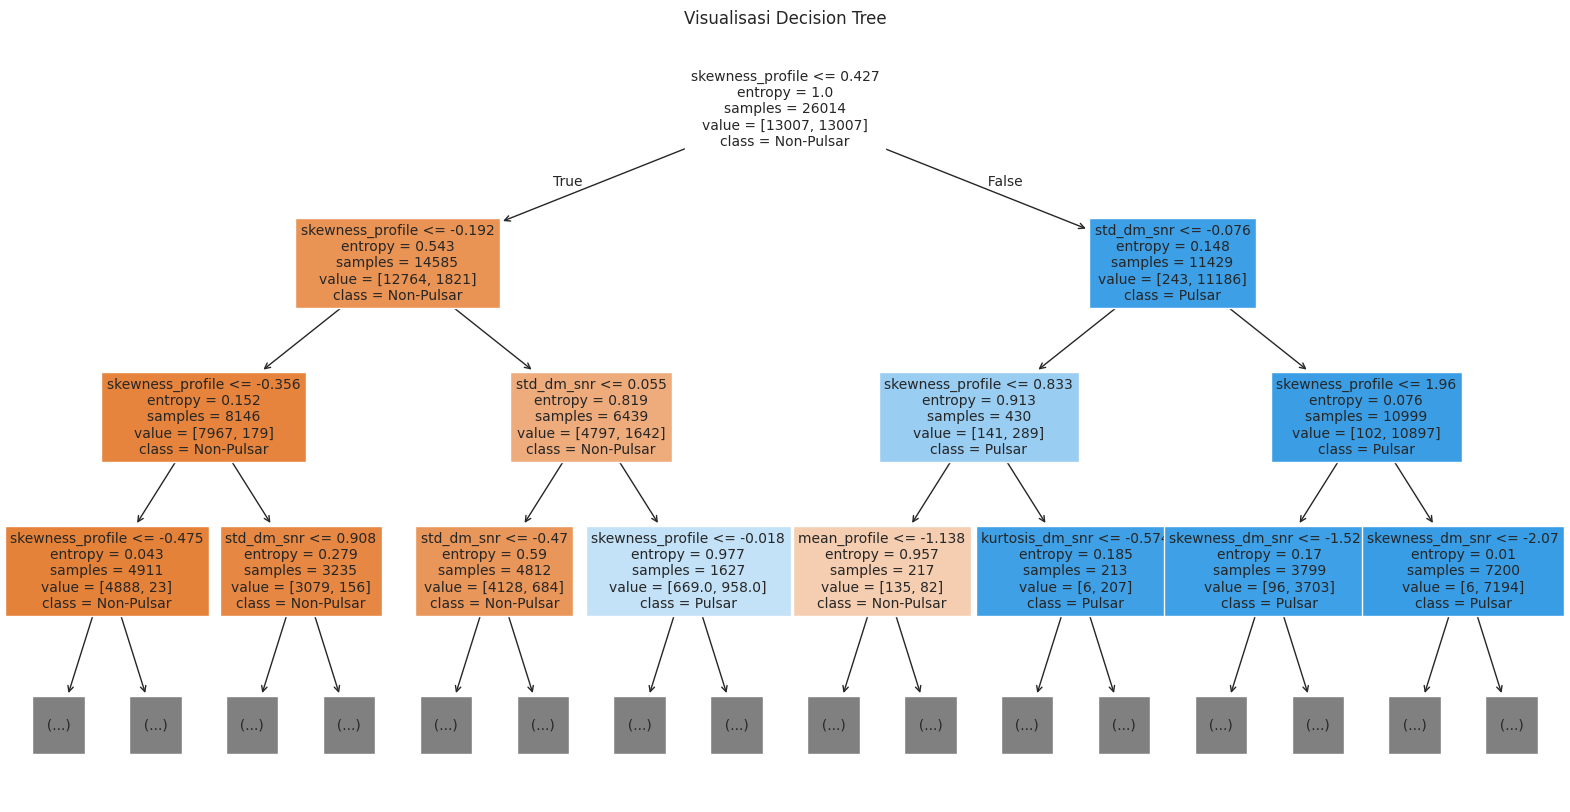

In [104]:
plt.figure(figsize=(20, 10))
plot_tree(
    best_dt_model,
    feature_names=X.columns, # type: ignore
    class_names=["Non-Pulsar", "Pulsar"],
    filled=True,
    max_depth=3,
    fontsize=10,
)
plt.title("Visualisasi Decision Tree")
plt.show()


## CLUSTERING

### Elbow Method

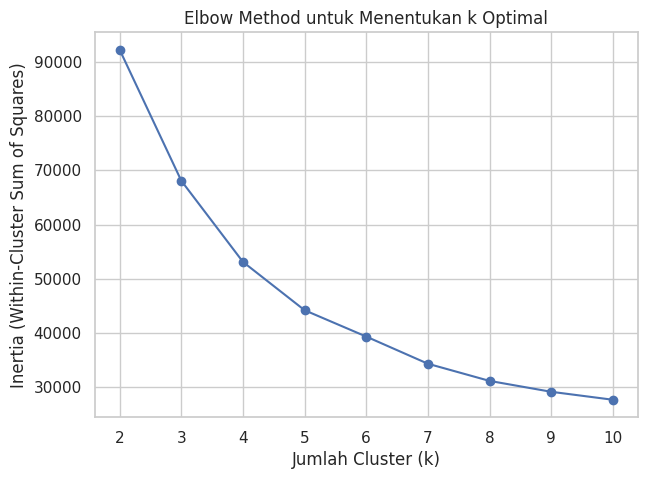

In [105]:
inertias = []
K_range = range(2, 11)  # k = 2 sampai 10

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(K_range, inertias, marker="o")
plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.title("Elbow Method untuk Menentukan k Optimal")
plt.xticks(K_range)
plt.show()

### Silhouette Score untuk Beberapa Nilai k

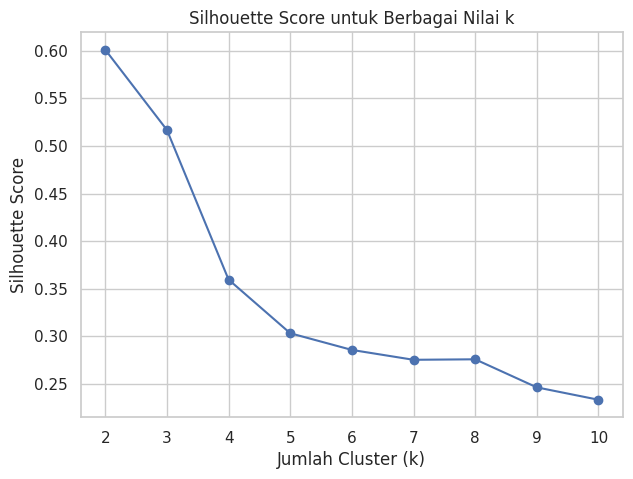

k = 2: Silhouette Score = 0.6010
k = 3: Silhouette Score = 0.5168
k = 4: Silhouette Score = 0.3596
k = 5: Silhouette Score = 0.3033
k = 6: Silhouette Score = 0.2858
k = 7: Silhouette Score = 0.2754
k = 8: Silhouette Score = 0.2760
k = 9: Silhouette Score = 0.2465
k = 10: Silhouette Score = 0.2335


In [106]:
sil_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = kmeans.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)

plt.figure(figsize=(7, 5))
plt.plot(K_range, sil_scores, marker="o")
plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score untuk Berbagai Nilai k")
plt.xticks(K_range)
plt.show()

for k, sil in zip(K_range, sil_scores):
    print(f"k = {k}: Silhouette Score = {sil:.4f}")

### Training K-Means dengan k Terpilih

In [107]:
best_k = 2

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Simpan label cluster ke dataframe untuk analisis
df_clusters = df.copy()
df_clusters["cluster"] = cluster_labels

df_clusters.head()


,mean_profile,std_profile,skewness_profile,kurtosis_profile,mean_dm_snr,std_dm_snr,skewness_dm_snr,kurtosis_dm_snr,class,cluster
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0,0


### Visualisasi Cluster dengan PCA 2D

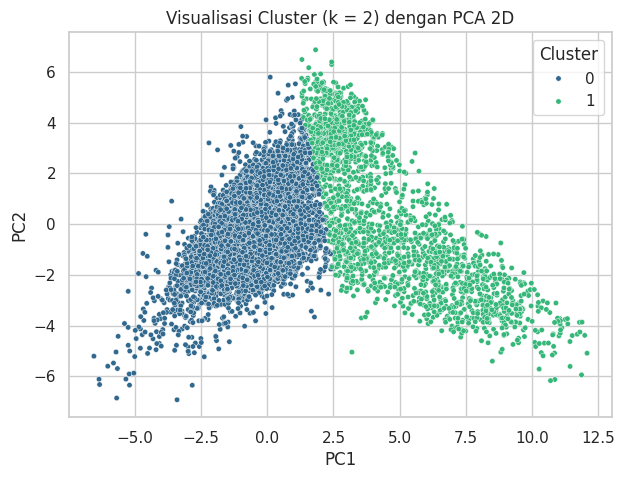

In [108]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))
sns.scatterplot(
    x=pca_data[:, 0], y=pca_data[:, 1], hue=cluster_labels, palette="viridis", s=15
)
plt.title(f"Visualisasi Cluster (k = {best_k}) dengan PCA 2D")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()


### Analisis Sederhana Setiap Cluster (Rata-rata Fitur)

In [109]:
cluster_summary = df_clusters.groupby("cluster").mean(numeric_only=True)
cluster_summary


,mean_profile,std_profile,skewness_profile,kurtosis_profile,mean_dm_snr,std_dm_snr,skewness_dm_snr,kurtosis_dm_snr,class
cluster,,,,,,,,,
0,115.870374,47.064924,0.228115,0.417639,4.110780,20.714607,9.254462,118.161425,0.022602
1,74.229442,42.584837,2.399014,12.175557,78.029079,69.496499,0.988650,2.517950,0.622147


### (Opsional) Gabungkan Cluster dengan Label Asli (Class)

In [110]:
crosstab = pd.crosstab(
    df_clusters["cluster"],
    df_clusters["class"],
    rownames=["Cluster"],
    colnames=["Class"],
)
crosstab


Class,0,1
Cluster,,
0,15481,358
1,778,1281
